<a href="https://colab.research.google.com/github/BrayFlo/Mineria-Datos/blob/main/Cluster_Codo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [15]:
#Crear el dataframe con los datos
data = {
    'Compras_Mes': [1, 2, 1.5, 10, 12, 11, 4, 5, 6],
    'Gasto_Mensual': [2, 3, 2.5, 9, 11, 10, 5, 6, 7]
}
df = pd.DataFrame(data)
df

,Compras_Mes,Gasto_Mensual
0,1.0,2.0
1,2.0,3.0
2,1.5,2.5
3,10.0,9.0
4,12.0,11.0
5,11.0,10.0
6,4.0,5.0
7,5.0,6.0
8,6.0,7.0


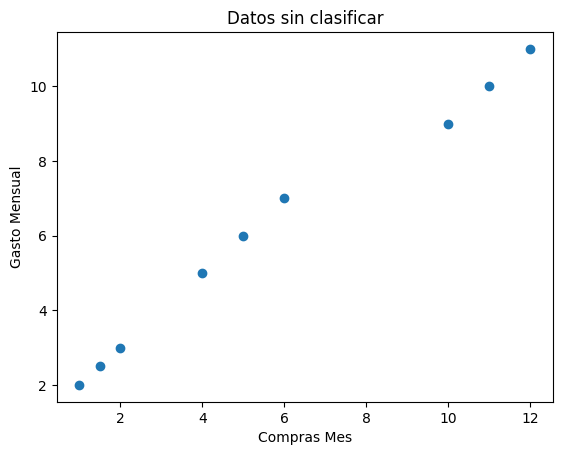

In [16]:
#2 Graficar los puntos sin cluster
plt.scatter(df['Compras_Mes'], df['Gasto_Mensual'])
plt.xlabel('Compras Mes')
plt.ylabel('Gasto Mensual')
plt.title('Datos sin clasificar')
plt.show()

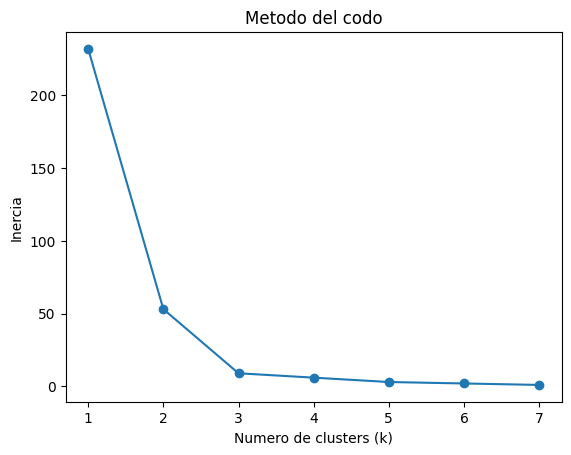

In [17]:
#3 Metodo del codo para encontrar k optimo
X = df[['Compras_Mes', 'Gasto_Mensual']].values
inertias = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

#Graficar el metodo del codo
plt.plot(range(1, 8), inertias, marker='o')
plt.xlabel('Numero de clusters (k)')
plt.ylabel('Inercia')
plt.title('Metodo del codo')
plt.show()


In [19]:
#Aplicamos k-means con k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)
df

,Compras_Mes,Gasto_Mensual,Cluster
0,1.0,2.0,1
1,2.0,3.0,1
2,1.5,2.5,1
3,10.0,9.0,2
4,12.0,11.0,2
5,11.0,10.0,2
6,4.0,5.0,0
7,5.0,6.0,0
8,6.0,7.0,0


In [20]:
#5 Mostrar los clusters
centroides = kmeans.cluster_centers_
centroides

array([[ 5. ,  6. ],
       [ 1.5,  2.5],
       [11. , 10. ]])

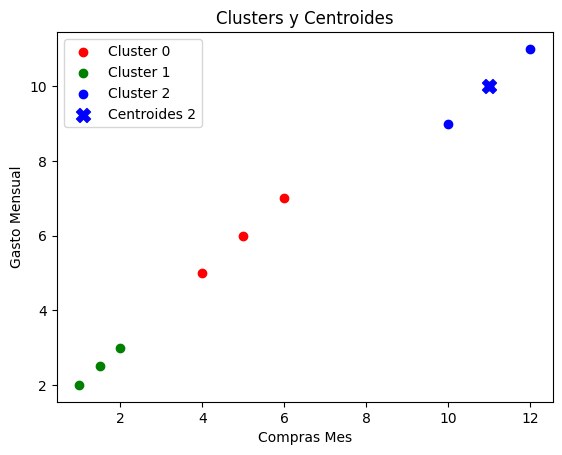

In [22]:
#Graficar los clusters con los centroides

colores = ['red', 'green', 'blue']

for i in range(3):
    puntos = df[df['Cluster'] == i]
    plt.scatter(puntos['Compras_Mes'], puntos['Gasto_Mensual'], c=colores[i], label=f'Cluster {i}')

plt.scatter(centroides[i, 0], centroides[i, 1], c=colores[i], marker='X', s=100, label =f'Centroides {i}')
plt.xlabel('Compras Mes')
plt.ylabel('Gasto Mensual')
plt.title('Clusters y Centroides')
plt.legend()
plt.show()

¿Qué tipo de clientes representa cada grupo?

Clientes Ocasionales / Bajo Consumo (Aprox. Cluster 0 o el grupo de menor valor):
Tienen un número muy bajo de compras al mes (entre 1 y 2) y su gasto también es mínimo (entre 2 y 3 cientos de pesos). Son clientes esporádicos que probablemente solo compran por necesidad puntual.

Clientes Promedio / Frecuencia Moderada (Aprox. Cluster 2 o el grupo intermedio):
Van a la tienda con una frecuencia moderada (4 a 6 veces al mes) y tienen un gasto equilibrado (5 a 7 cientos de pesos). Son la base estable de clientes de consumo medio.

Clientes VIP / De Alto Valor (Aprox. Cluster 1 o el grupo de mayor valor):
Son clientes altamente fieles y con un ticket alto. Tienen una frecuencia de compra sobresaliente (10 a 12 veces al mes) y además gastan bastante (9 a 11 cientos de pesos). A este grupo es al que normalmente se le dirigen campañas de fidelización exclusivas.